# Classificação com o Dataset Bank

**Aluno:** Pedro Pignata  
**Disciplina:** Aprendizado de Máquina  
**Atividade:** Avaliação 02 - Entrega Parcial 1 (Classificação)

## Apresentação

Este notebook apresenta o desenvolvimento completo de um problema de **classificação** a partir do dataset **Bank**. A proposta central é construir um modelo capaz de prever, com base no perfil do cliente e em suas características bancárias, se ele irá aderir ou não ao produto financeiro representado pela variável `pep`.


## 1. Definição do Problema

O problema neste trabalho é um problema de **classificação binária**, no qual o objetivo é prever se um cliente irá ou não aderir a um produto financeiro oferecido pelo banco. A base utilizada reúne informações cadastrais, demográficas e financeiras de clientes, permitindo analisar padrões de comportamento associados à adesão.

A variável-alvo do problema é a coluna `pep`, que indica se o cliente contratou ou não um **Personal Equity Plan** após a campanha promocional. Dessa forma, o modelo será treinado para aprender relações entre as características dos clientes e a decisão final de compra.

## 2. Importação das Bibliotecas



In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from scipy.stats import randint

try:
    from skopt import BayesSearchCV
    from skopt.space import Integer, Categorical
    bayes_available = True
except:
    bayes_available = False

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


### Ajuste de ambiente para Otimização Bayesiana

Esta célula instala a biblioteca necessária apenas caso ela não esteja disponível no ambiente, garantindo a execução da etapa de Otimização Bayesiana.


In [2]:
try:
    from skopt import BayesSearchCV
    from skopt.space import Integer, Categorical
    bayes_available = True
except:
    import sys
    !{sys.executable} -m pip install scikit-optimize -q
    from skopt import BayesSearchCV
    from skopt.space import Integer, Categorical
    bayes_available = True

print("BayesSearchCV disponível:", bayes_available)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00
BayesSearchCV disponível: True


## 3. Carregamento do Dataset



In [3]:
url = "https://raw.githubusercontent.com/klaytoncastro/idp-machinelearning/refs/heads/main/datasets/bank-data.csv"
df = pd.read_csv(url)

df.head()

,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,ID12101,48,FEMALE,INNER_CITY,17546.0,NO,1,NO,NO,NO,NO,YES
1,ID12102,40,MALE,TOWN,30085.1,YES,3,YES,NO,YES,YES,NO
2,ID12103,51,FEMALE,INNER_CITY,16575.4,YES,0,YES,YES,YES,NO,NO
3,ID12104,23,FEMALE,TOWN,20375.4,YES,3,NO,NO,YES,NO,NO
4,ID12105,57,FEMALE,RURAL,50576.3,YES,0,NO,YES,NO,NO,NO


In [4]:
print("Dimensões do dataset:", df.shape)
print("\nColunas do dataset:")
print(df.columns.tolist())

Dimensões do dataset: (600, 12)

Colunas do dataset:
['id', 'age', 'sex', 'region', 'income', 'married', 'children', 'car', 'save_act', 'current_act', 'mortgage', 'pep']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           600 non-null    object 
 1   age          600 non-null    int64  
 2   sex          600 non-null    object 
 3   region       600 non-null    object 
 4   income       600 non-null    float64
 5   married      600 non-null    object 
 6   children     600 non-null    int64  
 7   car          600 non-null    object 
 8   save_act     600 non-null    object 
 9   current_act  600 non-null    object 
 10  mortgage     600 non-null    object 
 11  pep          600 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 56.4+ KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,600,600,ID12700,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,600.0,NaN,NaN,NaN,42.395,14.424947,18.0,30.0,42.0,55.25,67.0
sex,600,2,FEMALE,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,600,4,INNER_CITY,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,600.0,NaN,NaN,NaN,27524.031217,12899.468246,5014.21,17264.5,24925.3,36172.675,63130.1
married,600,2,YES,396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
children,600.0,NaN,NaN,NaN,1.011667,1.056752,0.0,0.0,1.0,2.0,3.0
car,600,2,NO,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
save_act,600,2,YES,414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_act,600,2,YES,455,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A inspeção inicial mostra que a base reúne atributos de naturezas diferentes, incluindo variáveis numéricas e categóricas.

Além disso, a presença de uma variável-alvo binária torna o problema adequado à aplicação de classificadores supervisionados.

## 4. Análise Exploratória dos Dados



In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
id,0
age,0
sex,0
region,0
income,0
married,0
children,0
car,0
save_act,0
current_act,0


In [8]:
df["pep"].value_counts()

,count
pep,
NO,326
YES,274


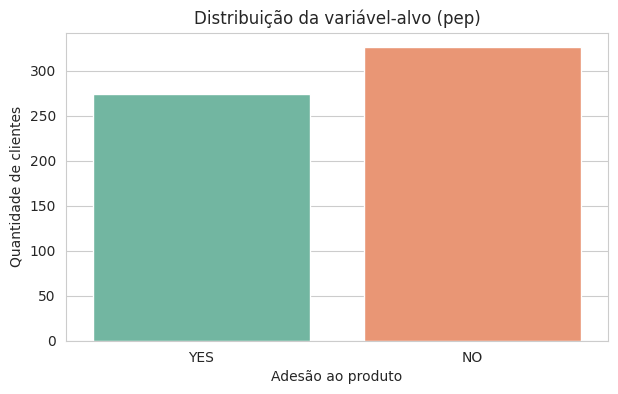

In [9]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="pep", palette="Set2")
plt.title("Distribuição da variável-alvo (pep)")
plt.xlabel("Adesão ao produto")
plt.ylabel("Quantidade de clientes")
plt.show()

### Variável-alvo

A variável `pep` representa a resposta que o modelo deverá prever. Observar sua distribuição é essencial porque um forte desbalanceamento entre as classes pode influenciar negativamente o treinamento do modelo, tornando algumas métricas mais relevantes do que outras.

Neste contexto, além da acurácia, métricas como precisão, recall e F1-score se tornam importantes, pois oferecem uma visão mais completa do desempenho do classificador em cada classe.

In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

if "pep" in categorical_cols:
    categorical_cols.remove("pep")

print("Variáveis numéricas:", numeric_cols)
print("\nVariáveis categóricas:", categorical_cols)

Variáveis numéricas: ['age', 'income', 'children']

Variáveis categóricas: ['id', 'sex', 'region', 'married', 'car', 'save_act', 'current_act', 'mortgage']


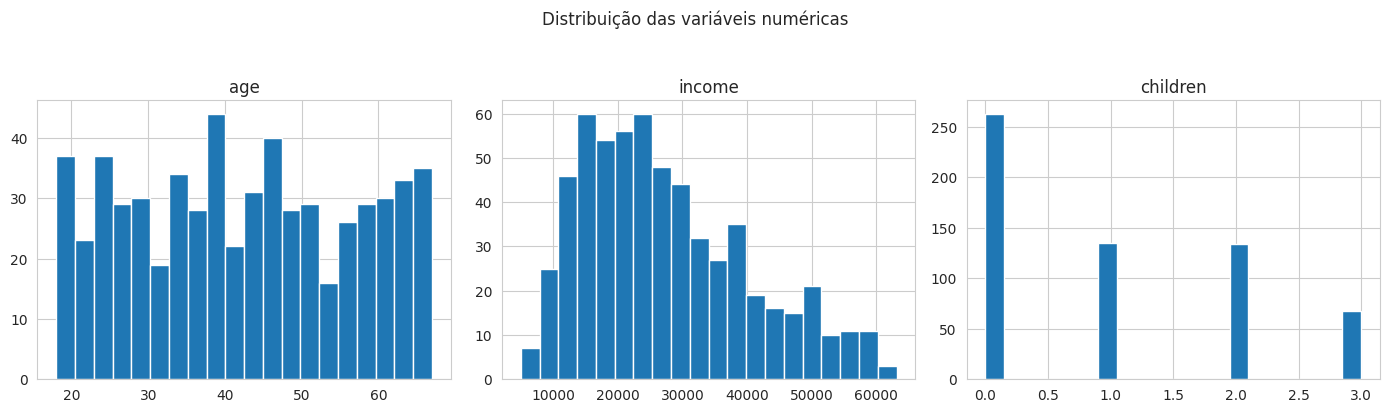

In [11]:
df[numeric_cols].hist(bins=20, figsize=(14, 10), layout=(3, 3))
plt.suptitle("Distribuição das variáveis numéricas", y=1.02)
plt.tight_layout()
plt.show()

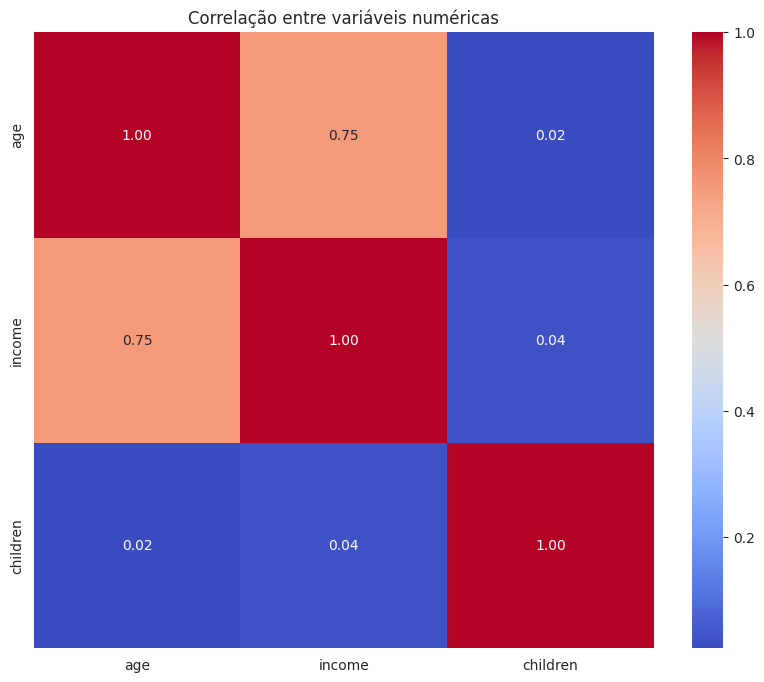

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre variáveis numéricas")
plt.show()

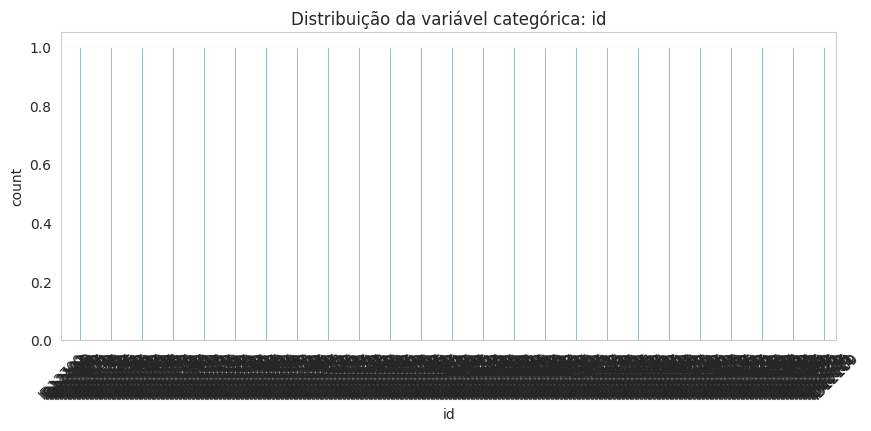

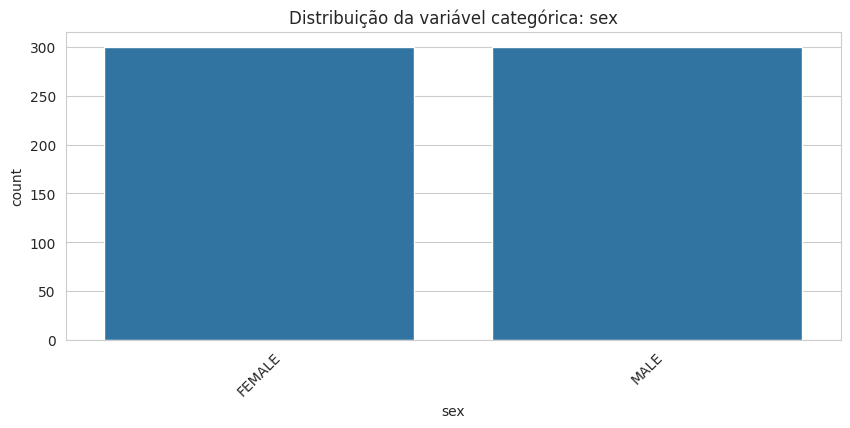

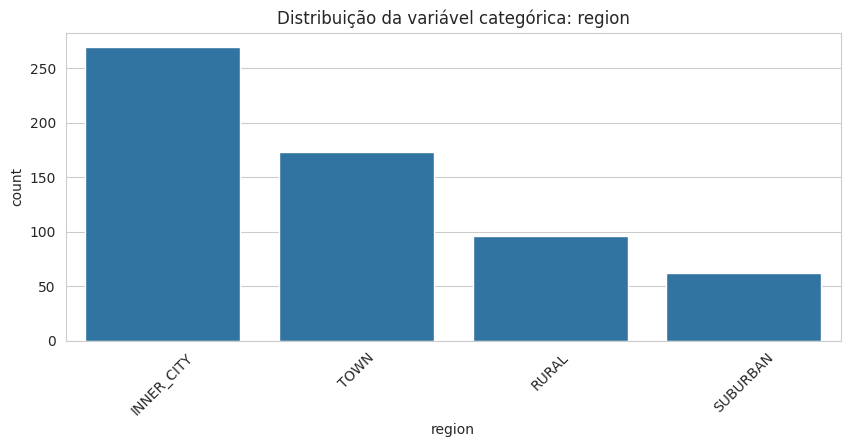

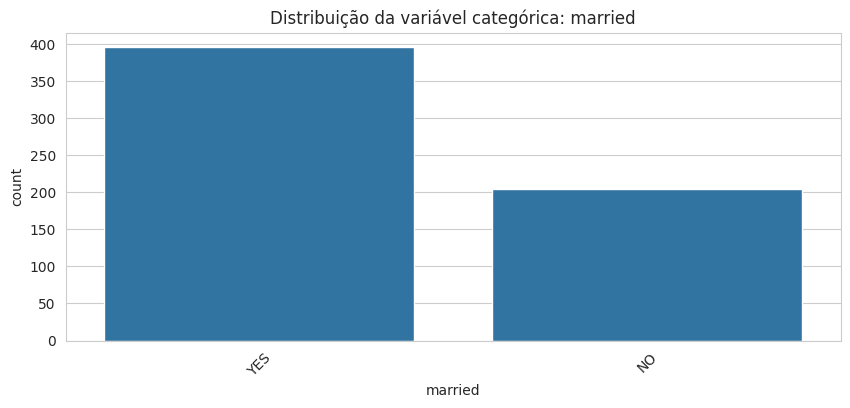

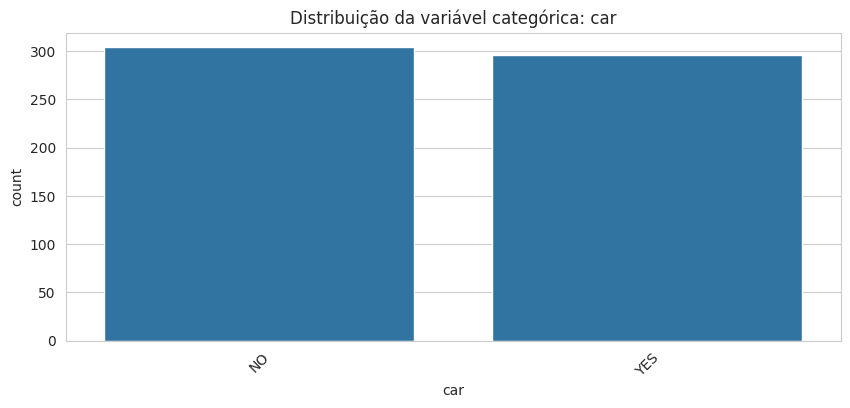

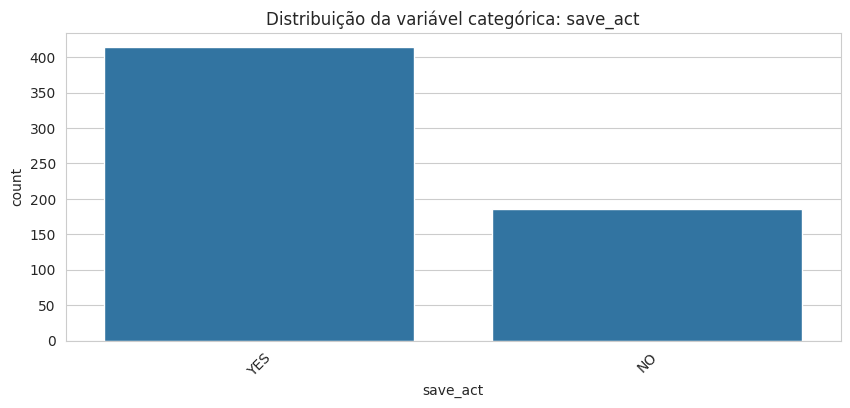

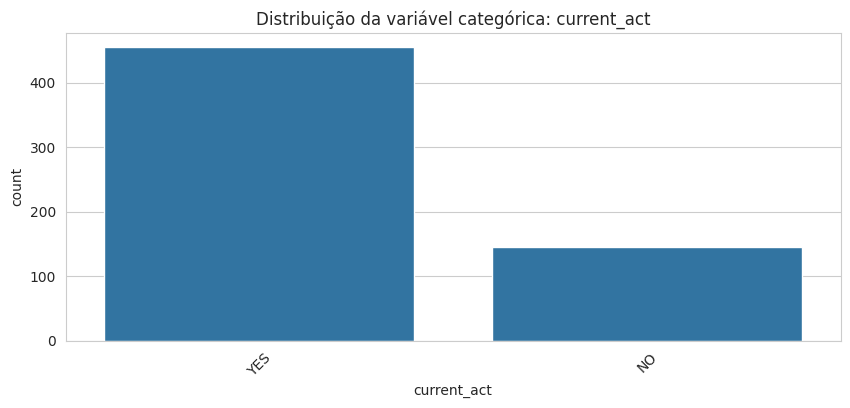

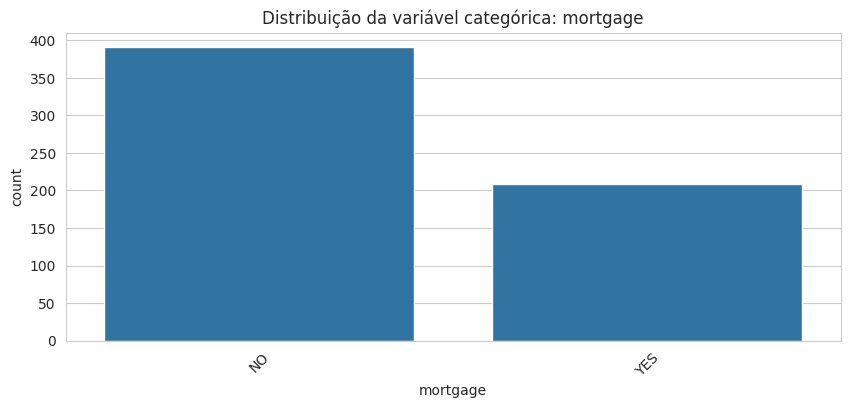

In [13]:
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribuição da variável categórica: {col}")
    plt.xticks(rotation=45)
    plt.show()

## 5. Pré-processamento


In [14]:
X = df.drop("pep", axis=1)
y = df["pep"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes codificadas:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Classes codificadas: {'NO': np.int64(0), 'YES': np.int64(1)}


In [15]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Conjunto de treino:", X_train.shape)
print("Conjunto de teste:", X_test.shape)

Conjunto de treino: (480, 11)
Conjunto de teste: (120, 11)


### Justificativa do pré-processamento

Usamos pipeline para garantir organização, reprodutibilidade e consistência no tratamento dos dados. Em vez de transformar manualmente cada variável, o pipeline aplica automaticamente o pré-processamento necessário dentro do próprio fluxo de treinamento do modelo.


## 6. Modelagem Inicial

Como ponto de partida, vamos usar o algoritmo **Random Forest Classifier**. A escolha desse modelo se justifica por sua boa capacidade de generalização em bases tabulares, por lidar bem com relações não lineares e por normalmente oferecer desempenho sólido mesmo sem ajustes finos iniciais.


In [17]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

start_time = time.time()
baseline_model.fit(X_train, y_train)
baseline_time = time.time() - start_time

y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Acurácia:", baseline_accuracy)
print("Precisão:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)
print("Tempo de execução (s):", baseline_time)

Acurácia: 0.7666666666666667
Precisão: 0.8292682926829268
Recall: 0.6181818181818182
F1-score: 0.7083333333333334
Tempo de execução (s): 1.0281853675842285


In [18]:
print(classification_report(y_test, y_pred_baseline, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

          NO       0.73      0.89      0.81        65
         YES       0.83      0.62      0.71        55

    accuracy                           0.77       120
   macro avg       0.78      0.76      0.76       120
weighted avg       0.78      0.77      0.76       120



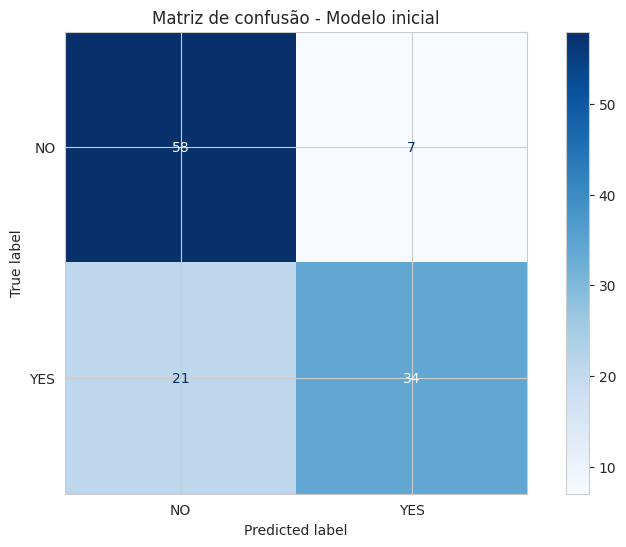

In [19]:
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de confusão - Modelo inicial")
plt.show()

## 7. Otimização com Grid Search

A primeira técnica de otimização utilizada é o **Grid Search**, que testa de forma exaustiva todas as combinações definidas em uma grade de hiperparâmetros.

In [20]:
grid_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

start_time = time.time()
grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred_grid)
grid_precision = precision_score(y_test, y_pred_grid)
grid_recall = recall_score(y_test, y_pred_grid)
grid_f1 = f1_score(y_test, y_pred_grid)

print("Melhores parâmetros:", grid_search.best_params_)
print("Acurácia:", grid_accuracy)
print("Precisão:", grid_precision)
print("Recall:", grid_recall)
print("F1-score:", grid_f1)
print("Tempo de execução (s):", grid_time)

Melhores parâmetros: {'classifier__max_depth': 30, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Acurácia: 0.775
Precisão: 0.8181818181818182
Recall: 0.6545454545454545
F1-score: 0.7272727272727273
Tempo de execução (s): 236.15036487579346


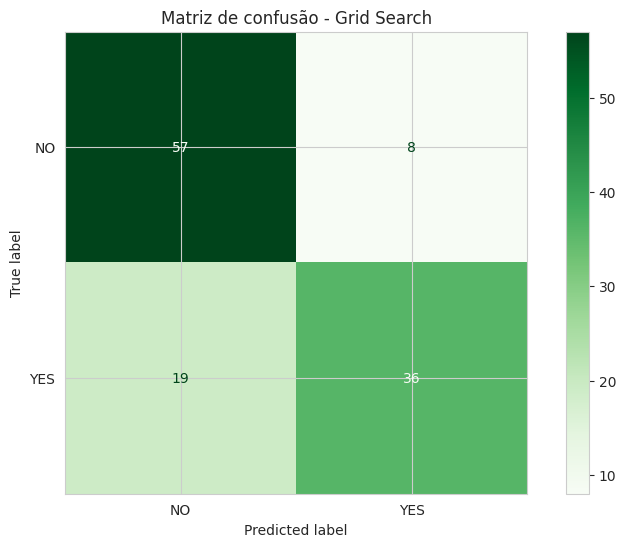

In [21]:
cm = confusion_matrix(y_test, y_pred_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Greens")
plt.title("Matriz de confusão - Grid Search")
plt.show()

A matriz de confusão do **Grid Search** permite observar não apenas os acertos totais, mas também como o modelo se comporta em cada classe. Isso ajuda a verificar se o ganho de desempenho veio de forma equilibrada ou se houve favorecimento excessivo de apenas uma das classes.


## 8. Otimização com Randomized Search

A segunda estratégia de otimização é o **Randomized Search**, que avalia apenas um subconjunto aleatório das combinações possíveis. Em vez de testar tudo, vamos explora o espaço de hiperparâmetros de forma mais econômica, o que o torna especialmente útil quando há restrições de tempo ou quando a grade de busca é muito grande.

In [22]:
random_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_dist = {
    "classifier__n_estimators": randint(100, 400),
    "classifier__max_depth": [None, 10, 20, 30, 40],
    "classifier__min_samples_split": randint(2, 12),
    "classifier__min_samples_leaf": randint(1, 6)
}

start_time = time.time()
random_search = RandomizedSearchCV(
    estimator=random_model,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)

random_accuracy = accuracy_score(y_test, y_pred_random)
random_precision = precision_score(y_test, y_pred_random)
random_recall = recall_score(y_test, y_pred_random)
random_f1 = f1_score(y_test, y_pred_random)

print("Melhores parâmetros:", random_search.best_params_)
print("Acurácia:", random_accuracy)
print("Precisão:", random_precision)
print("Recall:", random_recall)
print("F1-score:", random_f1)
print("Tempo de execução (s):", random_time)

Melhores parâmetros: {'classifier__max_depth': 30, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 158}
Acurácia: 0.775
Precisão: 0.8181818181818182
Recall: 0.6545454545454545
F1-score: 0.7272727272727273
Tempo de execução (s): 58.95814824104309


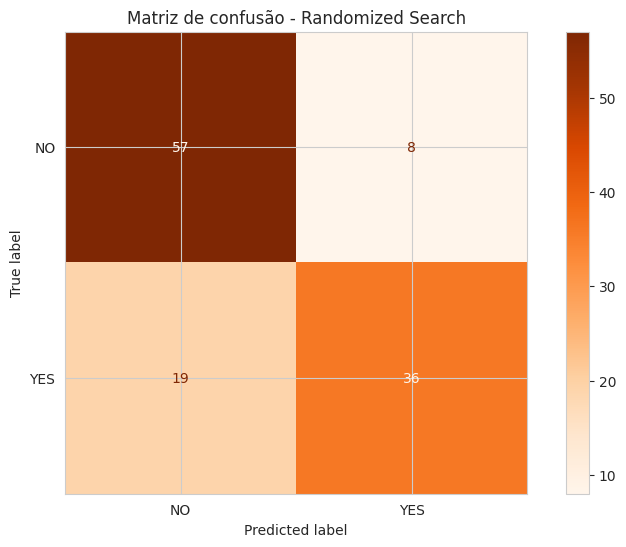

In [23]:
cm = confusion_matrix(y_test, y_pred_random)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Oranges")
plt.title("Matriz de confusão - Randomized Search")
plt.show()

Na matriz de confusão do **Randomized Search**, a leitura deve ser feita junto com as métricas agregadas. Como esse método alcançou desempenho semelhante ao Grid Search com menor custo computacional, essa visualização ajuda a confirmar se os erros cometidos também permaneceram em um nível comparável.


## 9. Otimização Bayesiana

A terceira e última estratégia de otimização utilizada será a **Otimização Bayesiana**, implementada com `BayesSearchCV`. Diferentemente das abordagens anteriores, ela utiliza os resultados obtidos nas iterações passadas para orientar a escolha das próximas combinações de hiperparâmetros.


In [24]:
if bayes_available:
    bayes_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ])

    search_spaces = {
        "classifier__n_estimators": Integer(100, 400),
        "classifier__max_depth": Integer(5, 40),
        "classifier__min_samples_split": Integer(2, 12),
        "classifier__min_samples_leaf": Integer(1, 6),
        "classifier__criterion": Categorical(["gini", "entropy"])
    }

    start_time = time.time()
    bayes_search = BayesSearchCV(
        estimator=bayes_model,
        search_spaces=search_spaces,
        n_iter=25,
        cv=5,
        scoring="f1",
        random_state=42,
        n_jobs=-1
    )
    bayes_search.fit(X_train, y_train)
    bayes_time = time.time() - start_time

    best_bayes_model = bayes_search.best_estimator_
    y_pred_bayes = best_bayes_model.predict(X_test)

    bayes_accuracy = accuracy_score(y_test, y_pred_bayes)
    bayes_precision = precision_score(y_test, y_pred_bayes)
    bayes_recall = recall_score(y_test, y_pred_bayes)
    bayes_f1 = f1_score(y_test, y_pred_bayes)

    print("Melhores parâmetros:", bayes_search.best_params_)
    print("Acurácia:", bayes_accuracy)
    print("Precisão:", bayes_precision)
    print("Recall:", bayes_recall)
    print("F1-score:", bayes_f1)
    print("Tempo de execução (s):", bayes_time)
else:
    print("A biblioteca scikit-optimize não está instalada. Instale com: pip install scikit-optimize")

Melhores parâmetros: OrderedDict({'classifier__criterion': 'entropy', 'classifier__max_depth': 40, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 400})
Acurácia: 0.7833333333333333
Precisão: 0.8222222222222222
Recall: 0.6727272727272727
F1-score: 0.74
Tempo de execução (s): 87.32742881774902


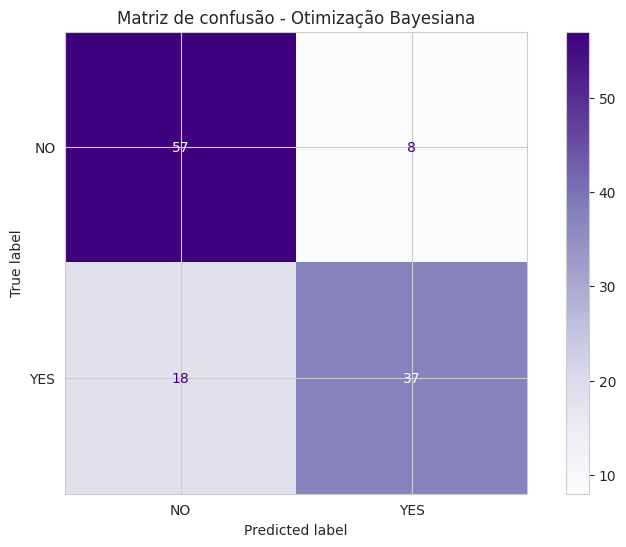

In [25]:
if bayes_available:
    cm = confusion_matrix(y_test, y_pred_bayes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap="Purples")
    plt.title("Matriz de confusão - Otimização Bayesiana")
    plt.show()

A matriz de confusão da **Otimização Bayesiana** complementa a comparação final, mostrando se a busca bayesiana conseguiu melhorar a identificação da classe positiva sem aumentar demais os falsos positivos. Essa análise visual é útil para interpretar o ganho prático do ajuste de hiperparâmetros.


## 10. Comparação dos Resultados

Depois de aplicar o modelo inicial e as três estratégias de otimização, torna-se possível realizar uma comparação consolidada entre os resultados.

In [26]:
results = {
    "Modelo": ["Inicial", "Grid Search", "Randomized Search"],
    "Acurácia": [baseline_accuracy, grid_accuracy, random_accuracy],
    "Precisão": [baseline_precision, grid_precision, random_precision],
    "Recall": [baseline_recall, grid_recall, random_recall],
    "F1-score": [baseline_f1, grid_f1, random_f1],
    "Tempo (s)": [baseline_time, grid_time, random_time]
}

if bayes_available:
    results["Modelo"].append("Otimização Bayesiana")
    results["Acurácia"].append(bayes_accuracy)
    results["Precisão"].append(bayes_precision)
    results["Recall"].append(bayes_recall)
    results["F1-score"].append(bayes_f1)
    results["Tempo (s)"].append(bayes_time)

results_df = pd.DataFrame(results)
results_df

,Modelo,Acurácia,Precisão,Recall,F1-score,Tempo (s)
0,Inicial,0.766667,0.829268,0.618182,0.708333,1.028185
1,Grid Search,0.775000,0.818182,0.654545,0.727273,236.150365
2,Randomized Search,0.775000,0.818182,0.654545,0.727273,58.958148
3,Otimização Bayesiana,0.783333,0.822222,0.672727,0.740000,87.327429


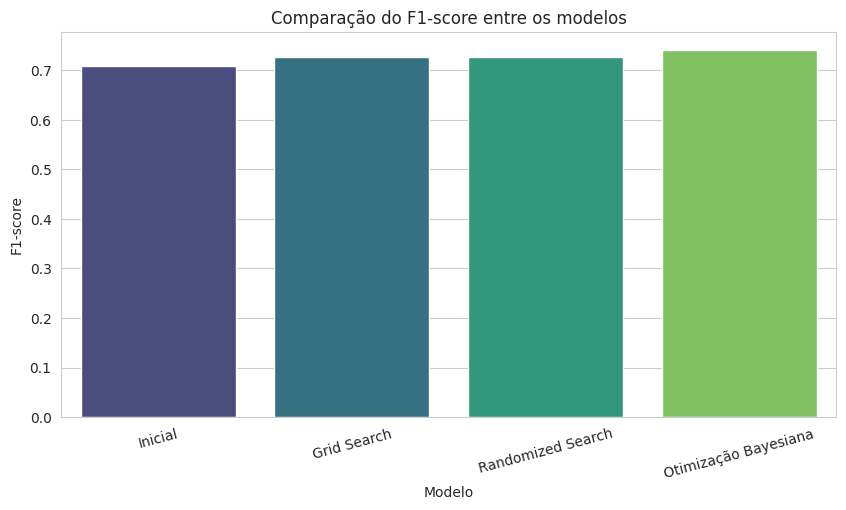

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Modelo", y="F1-score", palette="viridis")
plt.title("Comparação do F1-score entre os modelos")
plt.xticks(rotation=15)
plt.show()

## Discussão dos resultados

A comparação final deixa mais claro o efeito das estratégias de otimização sobre o desempenho do modelo. Como o objetivo é classificar corretamente a adesão ao produto financeiro, o F1-score faz sentido como métrica principal, já que ele equilibra precisão e recall e evita uma análise limitada só à acurácia.

Nos resultados obtidos, tanto o Grid Search quanto o Randomized Search superaram o modelo inicial em recall e F1-score. Isso é importante porque, neste contexto, aumentar o recall significa reduzir a quantidade de clientes que realmente adeririam ao produto, mas que o modelo deixaria de identificar.

Outro ponto interessante é o custo computacional. Mesmo com desempenho praticamente igual ao do Grid Search, o Randomized Search conseguiu chegar ao mesmo F1-score com um tempo de execução bem menor, o que mostra uma relação custo-benefício melhor para esse experimento.

Se a etapa de Otimização Bayesiana for executada corretamente no ambiente, ela entra como uma terceira alternativa relevante, principalmente por buscar combinações promissoras de hiperparâmetros de forma mais inteligente. Em muitos cenários, isso permite encontrar bons resultados sem testar exaustivamente todas as combinações possíveis.


## 11. Conclusão

Neste notebook, foi desenvolvido um fluxo completo de aprendizado de máquina para um problema de classificação com o dataset Bank. O objetivo foi prever a variável `pep`, que representa a adesão ou não do cliente ao produto financeiro após a campanha realizada pelo banco.

A análise exploratória ajudou a entender melhor a composição da base, o tipo das variáveis e a necessidade de um pré-processamento adequado para lidar com atributos numéricos e categóricos. A partir disso, foi construído um pipeline de preparação dos dados e treinado um modelo inicial com Random Forest, utilizado como ponto de partida para as comparações.

Em seguida, foram aplicadas diferentes estratégias de otimização de hiperparâmetros. Os resultados mostraram que houve melhora em relação ao modelo inicial, principalmente no recall e no F1-score, indicando um ganho mais equilibrado na capacidade preditiva do classificador.

Entre os métodos testados até aqui, o Randomized Search se destacou por alcançar desempenho equivalente ao Grid Search com menor tempo de execução, o que o torna uma alternativa mais eficiente neste cenário. Já a Otimização Bayesiana complementa a análise por oferecer uma forma mais direcionada de explorar o espaço de hiperparâmetros.

De modo geral, o trabalho mostrou que o desempenho final de um modelo não depende apenas da escolha do algoritmo, mas também da forma como os dados são preparados, das métricas escolhidas para avaliação e da estratégia usada para ajustar os hiperparâmetros. Isso reforça a importância de enxergar o processo de modelagem como um fluxo completo, e não só como a etapa de treinamento do modelo.


In [28]:
results_df.sort_values(by="F1-score", ascending=False)

,Modelo,Acurácia,Precisão,Recall,F1-score,Tempo (s)
3,Otimização Bayesiana,0.783333,0.822222,0.672727,0.740000,87.327429
1,Grid Search,0.775000,0.818182,0.654545,0.727273,236.150365
2,Randomized Search,0.775000,0.818182,0.654545,0.727273,58.958148
0,Inicial,0.766667,0.829268,0.618182,0.708333,1.028185
